In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.colors as colors
import h5py as h5py # data storing


# import biblioteki z funkcjami do mumaxa
import sys
sys.path.insert(0, 'C:\Users\Pawel\OneDrive\mumax_fragmenty_kodu\mumax_lib')
import mumax_lib as mx_lib

%matplotlib inline
sqrt = np.sqrt
pi = np.pi
exp = np.exp
sin = np.sin
cos = np.cos
mu0 = np.pi*4e-07
plt.rcParams['figure.figsize'] = (12.0, 5.0)

pcolors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',]

In [2]:
# import numba
# from numba import double
from timeit import default_timer as timer
import numpy as np
import struct

def saveOVF_6vec(vec, xyzLi, output):
	# save2File(vec, output, showPlot=True)
 	# saving 6 rows of dato to ovf file, where: 
 	# [x, y, z,  bx, by, bz] = vec
 	# output - addres of file to save
    
    [x, y, z,  bx, by, bz] = vec
    [xLi, yLi, zLi] = xyzLi
    ## SAVING
    print(len(x), len(y), len(z), len(bx), len(by), len(bz))
    # [xLi, yLi, zLi] = [[], [], []]  # serted lists with no repeting elements
    # print "arrays completing..."
    # ts = timer()
    # [xLi.append(item) for item in x if item not in xLi]
    # [yLi.append(item) for item in y if item not in yLi]
    # [zLi.append(item) for item in z if item not in zLi]
    # tf = timer()
    # print tf-ts
    # [xLi, yLi, zLi] = [sorted(xLi), sorted(yLi), sorted(zLi)]
    [xShift, yShift, zShift] = [xLi[0], yLi[0], zLi[0]]
    
    ts = timer()
    addr = output
    f = open(addr, 'w+b')
    try: zDiff = abs(zLi[1]-zLi[0])
    except: zDiff = 0
    head = "# OOMMF OVF 2.0"+ \
            "\n# Segment count: 1 \n"+ \
            "# Begin: Segment \n"+ \
            "# Begin: Header \n"+ \
            "# Title: B_ext \n"+ \
            "# meshtype: rectangular \n"+ \
            "# meshunit: m \n"+ \
            "# \n" + "# xmin: 0 \n# ymin: 0 \n# zmin: 0 "+ \
            "\n# xmax: " + str(max(xLi)+xShift) + "\n# ymax: " + str(max(yLi)+yShift) + "\n# zmax: "+ str(max(zLi)+zShift) + "\n"+ \
            "# valuedim: 3 \n"+ \
            "# valuelabels: B_ext_x B_ext_y B_ext_z \n"+ \
            "# Desc: Total simulation time:  3.7695141020683983e-11  s\n" +\
            "# valueunits: T T T \n"+ \
            "# xbase: " + str(abs(xLi[1]-xLi[0])/2) +" \n"+ \
            "# ybase: " + str(abs(yLi[1]-yLi[0])/2) +" \n"+ \
            "# zbase: " + str(zDiff/2) +" \n"+ \
            "# xnodes: "+ str(len(xLi))+" \n"+ \
            "# ynodes: "+ str(len(yLi))+" \n"+ \
            "# znodes: "+ str(len(zLi))+" \n"+ \
            "# xstepsize: " + str(abs(xLi[1]-xLi[0])) +" \n"+ \
            "# ystepsize: " + str(abs(yLi[1]-yLi[0])) +" \n"+ \
            "# zstepsize: " + str(zDiff) +" \n"+ \
            "# End: Header \n"+ \
            "# Begin: Data Binary 4 \n" 
    print(head)
    f.write(head.encode("UTF-8"))
    s = ""
    txt = ""
    
    print("saving to file...")
    f.write( struct.pack('f', (1234567.0) ))
    print(len(x), len(bx), len(by), len(bz))
    print len(x), len(bx)
    for i in range(len(x)):
        f.write( struct.pack('f', (bx[i])))
        f.write( struct.pack('f', (by[i])))
        f.write( struct.pack('f', (bz[i])))
    f.write("# End: data text \n# End: segment".encode("UTF-8"))
    print("file saved")
    f.close()
    tf = timer()
    print "saving time: ", tf-ts

    print("done.")

# @numba.autojit
def matrix2lists(Mx, My, Mz, cx, cy):
    xr, yr, zr, MLi = [], [], [],  [[], [], []]
    print Mx.shape
    Nx, Ny, Nz = Mx.shape[1], Mx.shape[0], 0
    xLi = list(np.array(range(Nx)) * cx)
    zerosLi = list(np.zeros(Nx))
#     MLi = [ Mx.flatten('C'), My.flatten('C'), Mz.flatten('C')  ]
#     print type(MLi)
#     print len(xLi)
    for y in range(Ny):
#         print y
#         Blist[0] += Mx[y,:].tolist()
        MLi[0] += list(Mx[y,:])
        MLi[1] += list(My[y])
        MLi[2] += list(Mz[y])
        xr += xLi
        yr += list( np.ones( (Nx) )*y*cy)
        zr += zerosLi
    print "done"
    return xr, yr, zr, MLi

def saveArrAsOVF(fName, Mx, My, Mz, cx, cy):
    # preparing lists to save as OVF file
    xr, yr, zr, br = matrix2lists(Mx, My, Mz, cx, cy) 
    xLi = list(np.array(range(Mx.shape[1])) * cx)
    yLi = list(np.array(range(Mx.shape[0])) * cy)
    zLi = [0]
    print "Lists prepared. SAVING..."
    print len(xr), len(br[0])
    saveOVF_6vec([xr, yr, zr,  br[0], br[1], br[2]], [xLi, yLi, zLi], fName)
    
    

(100L, 300L)
done
Lists prepared. SAVING...
30000 30000
(30000, 30000, 30000, 30000, 30000, 30000)
# OOMMF OVF 2.0
# Segment count: 1 
# Begin: Segment 
# Begin: Header 
# Title: B_ext 
# meshtype: rectangular 
# meshunit: m 
# 
# xmin: 0 
# ymin: 0 
# zmin: 0 
# xmax: 1.495e-06
# ymax: 4.95e-07
# zmax: 0
# valuedim: 3 
# valuelabels: B_ext_x B_ext_y B_ext_z 
# Desc: Total simulation time:  3.7695141020683983e-11  s
# valueunits: T T T 
# xbase: 2.5e-09 
# ybase: 2.5e-09 
# zbase: 0 
# xnodes: 300 
# ynodes: 100 
# znodes: 1 
# xstepsize: 5e-09 
# ystepsize: 5e-09 
# zstepsize: 0 
# End: Header 
# Begin: Data Binary 4 

saving to file...
(30000, 30000, 30000, 30000)
30000 30000
file saved
saving time:  0.063348364484
done.
(300L, 100L, 1L, 3L)


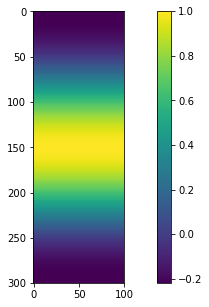

In [3]:
cx, cy = 5e-09, 5e-09
# arr = np.ones( (100, 200))
Mx = np.ones( (100, 300))
My = Mx*2
for i in range(My.shape[0]):
    for j in range(My.shape[1]):
        My[i, j] = np.sinc( 0.01*abs(j-My.shape[1]/2))
Mz = Mx*0
fName = "test1.ovf"
saveArrAsOVF(fName, Mx, My, Mz, cx, cy)


(M, h0, ec0) = mx_lib.loadOVF(fName, oneComp=False)
print M.shape
plt.imshow(M[:,:,0,1])
plt.colorbar()

(300L, 100L, 1L, 3L)


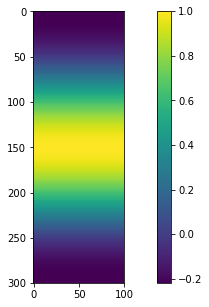

In [4]:

(M, h0, ec0) = mx_lib.loadOVF(fName, oneComp=False)
print M.shape

plt.imshow(M[:,:,0,1])
plt.colorbar()